# 4. Guided project — Persian corpus visualization report

This project combines the core skills from the previous notebooks into a reproducible mini-report. You will audit a synthetic Persian corpus, calculate normalized linguistic measures, build a multi-panel dashboard, write an interpretation, and export publication-ready figures.

## Project brief

A research team has assembled a Persian dataset containing textbook passages, learner essays, news articles, and social-media posts. The team needs a visualization report answering:

1. Is the corpus balanced across sources?
2. How do document lengths differ by source?
3. Which sources have the highest metaphor and learner-error rates after normalization?
4. How does emotion prevalence change over time?
5. Can the key findings be communicated in one publication-ready dashboard?

## Deliverables

- a reproducible synthetic dataset;
- a corpus-quality audit;
- at least four appropriate plots;
- one multi-panel final figure;
- a short written interpretation;
- PNG, SVG, and PDF exports;
- extension exercises and reference solutions.


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RNG = np.random.default_rng(1403)

plt.rcParams.update({
    "figure.figsize": (8.5, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

print("Matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)


Matplotlib: 3.10.8
pandas: 2.2.3


## 1. Create the project dataset

Real projects should load a versioned CSV or Parquet file. Here we generate synthetic document-level data so the notebook runs without external files. Every row represents one document.


In [2]:
source_specs = {
    "Textbooks": {"n": 120, "mean_tokens": 420, "year_min": 2021},
    "Learner essays": {"n": 260, "mean_tokens": 280, "year_min": 2022},
    "News": {"n": 340, "mean_tokens": 510, "year_min": 2021},
    "Social media": {"n": 700, "mean_tokens": 95, "year_min": 2022},
}
emotions = np.array(["joy", "sadness", "anger", "fear", "neutral"])

rows = []
doc_id = 1
for source, spec in source_specs.items():
    for _ in range(spec["n"]):
        tokens = max(20, int(RNG.lognormal(np.log(spec["mean_tokens"]), 0.48)))
        year = int(RNG.integers(spec["year_min"], 2027))
        metaphor_rate = {
            "Textbooks": 0.0045,
            "Learner essays": 0.0060,
            "News": 0.0080,
            "Social media": 0.0105,
        }[source]
        error_rate = {
            "Textbooks": 0.0015,
            "Learner essays": 0.0220,
            "News": 0.0020,
            "Social media": 0.0130,
        }[source]
        emotion_probs = {
            "Textbooks": [0.18, 0.10, 0.07, 0.05, 0.60],
            "Learner essays": [0.20, 0.18, 0.11, 0.09, 0.42],
            "News": [0.09, 0.17, 0.13, 0.12, 0.49],
            "Social media": [0.23, 0.16, 0.19, 0.08, 0.34],
        }[source]

        rows.append({
            "document_id": f"doc_{doc_id:04d}",
            "source": source,
            "year": year,
            "tokens": tokens,
            "sentences": max(1, int(tokens / RNG.uniform(14, 24))),
            "types": min(tokens, int(tokens ** RNG.uniform(0.72, 0.82))),
            "metaphor_tokens": int(RNG.poisson(tokens * metaphor_rate)),
            "error_tokens": int(RNG.poisson(tokens * error_rate)),
            "emotion": RNG.choice(emotions, p=emotion_probs),
        })
        doc_id += 1

corpus = pd.DataFrame(rows)
corpus.head()


,document_id,source,year,tokens,sentences,types,metaphor_tokens,error_tokens,emotion
0,doc_0001,Textbooks,2024,437,26,103,2,0,neutral
1,doc_0002,Textbooks,2021,529,34,145,1,1,neutral
2,doc_0003,Textbooks,2022,615,38,163,3,0,joy
3,doc_0004,Textbooks,2025,470,19,87,1,0,neutral
4,doc_0005,Textbooks,2023,595,26,177,4,0,neutral


## 2. Audit the data before plotting

Visualization cannot repair incorrect units or missing data. Confirm row count, dtypes, missingness, duplicate identifiers, and impossible values first.


In [3]:
audit = pd.DataFrame({
    "dtype": corpus.dtypes.astype(str),
    "missing": corpus.isna().sum(),
    "unique": corpus.nunique(),
})

print("Rows:", len(corpus))
print("Duplicate document IDs:", corpus["document_id"].duplicated().sum())
print("Non-positive token counts:", (corpus["tokens"] <= 0).sum())
audit


Rows: 1420
Duplicate document IDs: 0
Non-positive token counts: 0


,dtype,missing,unique
document_id,object,0,1420
source,object,0,4
year,int64,0,6
tokens,int64,0,581
sentences,int64,0,77
types,int64,0,220
metaphor_tokens,int64,0,20
error_tokens,int64,0,22
emotion,object,0,5


## 3. Corpus composition and balance

Report both documents and tokens. A source may contain many short documents but fewer total tokens than a source with fewer long documents.


In [4]:
source_summary = (
    corpus.groupby("source", observed=True)
    .agg(documents=("document_id", "size"), tokens=("tokens", "sum"), median_tokens=("tokens", "median"))
    .sort_values("tokens", ascending=False)
)
source_summary


,documents,tokens,median_tokens
source,,,
News,340,201717,512.0
Social media,700,77658,98.0
Learner essays,260,77656,270.0
Textbooks,120,56596,426.0


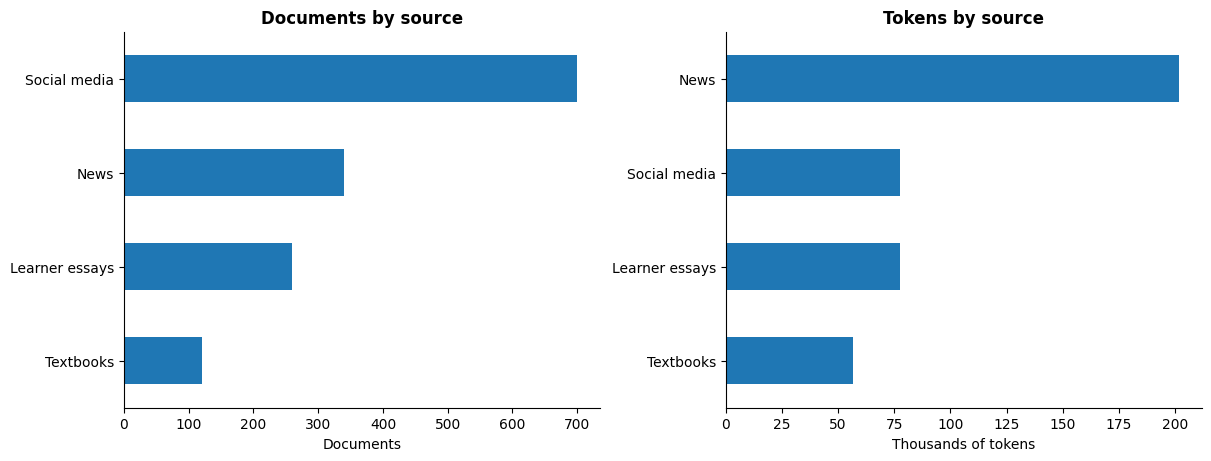

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

source_summary.sort_values("documents")["documents"].plot.barh(ax=axes[0])
axes[0].set(title="Documents by source", xlabel="Documents", ylabel="")

(source_summary.sort_values("tokens")["tokens"] / 1_000).plot.barh(ax=axes[1])
axes[1].set(title="Tokens by source", xlabel="Thousands of tokens", ylabel="")

plt.show()


## 4. Document-length distributions

Medians and full distributions reveal information hidden by totals. Because document lengths are right-skewed, use a log-scaled x-axis for the box plot.


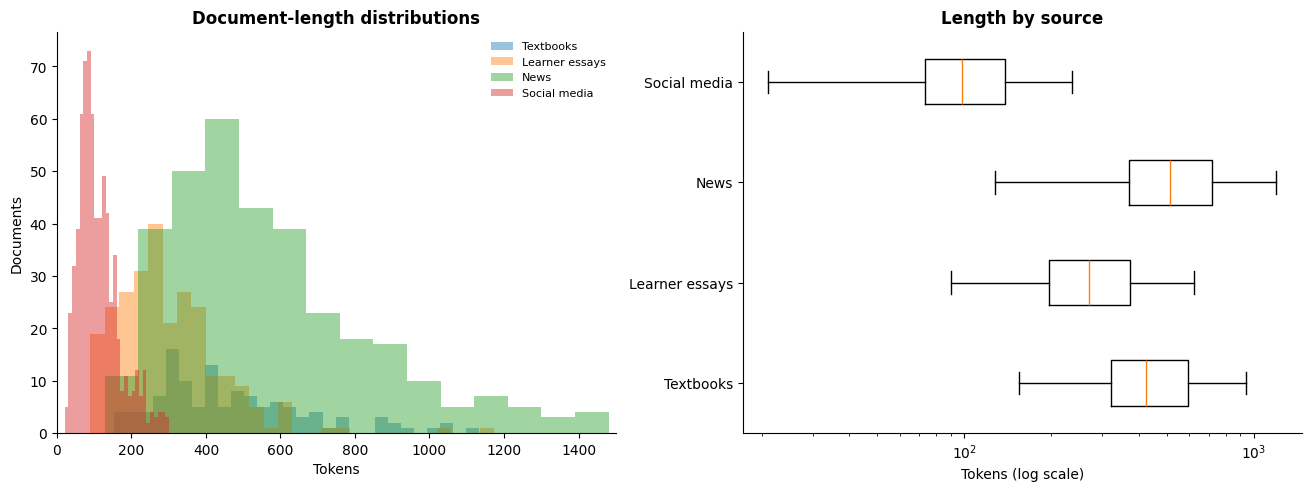

In [6]:
source_order = ["Textbooks", "Learner essays", "News", "Social media"]
length_groups = [corpus.loc[corpus["source"] == source, "tokens"] for source in source_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")

for source, values in zip(source_order, length_groups):
    axes[0].hist(values, bins=28, alpha=0.45, label=source)
axes[0].set(title="Document-length distributions", xlabel="Tokens", ylabel="Documents", xlim=(0, 1_500))
axes[0].legend(fontsize=8)

axes[1].boxplot(length_groups, tick_labels=source_order, vert=False, showfliers=False)
axes[1].set(title="Length by source", xlabel="Tokens (log scale)")
axes[1].set_xscale("log")

plt.show()


## 5. Normalize linguistic phenomena

Raw counts are not comparable when source sizes differ. Here we calculate rates per 10,000 tokens at document level, then summarize their means and 95% confidence intervals by source.


In [7]:
corpus = corpus.assign(
    metaphors_per_10k=corpus["metaphor_tokens"] / corpus["tokens"] * 10_000,
    errors_per_10k=corpus["error_tokens"] / corpus["tokens"] * 10_000,
)

def mean_ci(group: pd.Series) -> pd.Series:
    mean = group.mean()
    se = group.std(ddof=1) / np.sqrt(group.size)
    return pd.Series({"mean": mean, "low": mean - 1.96 * se, "high": mean + 1.96 * se})

metaphor_summary = corpus.groupby("source")["metaphors_per_10k"].apply(mean_ci).unstack()
error_summary = corpus.groupby("source")["errors_per_10k"].apply(mean_ci).unstack()
metaphor_summary


,mean,low,high
source,,,
Learner essays,56.824579,50.933851,62.715306
News,79.672825,75.064864,84.280785
Social media,96.229898,88.418932,104.040864
Textbooks,41.333227,35.715855,46.950598


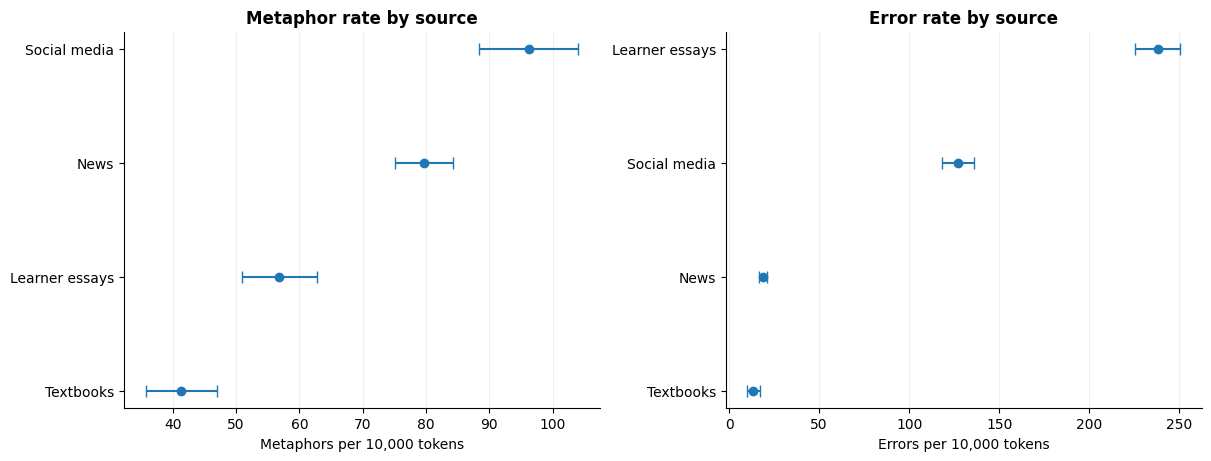

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

for ax, summary, title, ylabel in [
    (axes[0], metaphor_summary, "Metaphor rate by source", "Metaphors per 10,000 tokens"),
    (axes[1], error_summary, "Error rate by source", "Errors per 10,000 tokens"),
]:
    ordered = summary.sort_values("mean")
    xerr = np.vstack([ordered["mean"] - ordered["low"], ordered["high"] - ordered["mean"]])
    ax.errorbar(ordered["mean"], ordered.index, xerr=xerr, fmt="o", capsize=4)
    ax.set(title=title, xlabel=ylabel, ylabel="")
    ax.grid(axis="x", alpha=0.2)

plt.show()


## 6. Emotion prevalence over time

Plot proportions within each year so changes in corpus volume do not masquerade as prevalence changes.


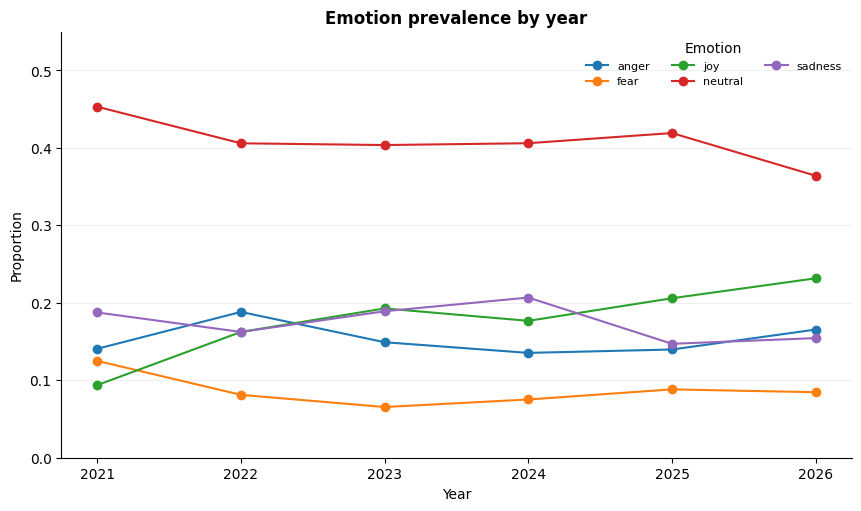

In [9]:
emotion_counts = pd.crosstab(corpus["year"], corpus["emotion"])
emotion_proportions = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(layout="constrained")
emotion_proportions.plot(marker="o", ax=ax)
ax.set(title="Emotion prevalence by year", xlabel="Year", ylabel="Proportion", ylim=(0, 0.55))
ax.legend(title="Emotion", ncols=3, fontsize=8)
ax.grid(axis="y", alpha=0.2)
plt.show()


## 7. Build the final multi-panel report

A good dashboard has a clear reading order, consistent terminology, restrained color, and enough annotation to stand alone outside the notebook.


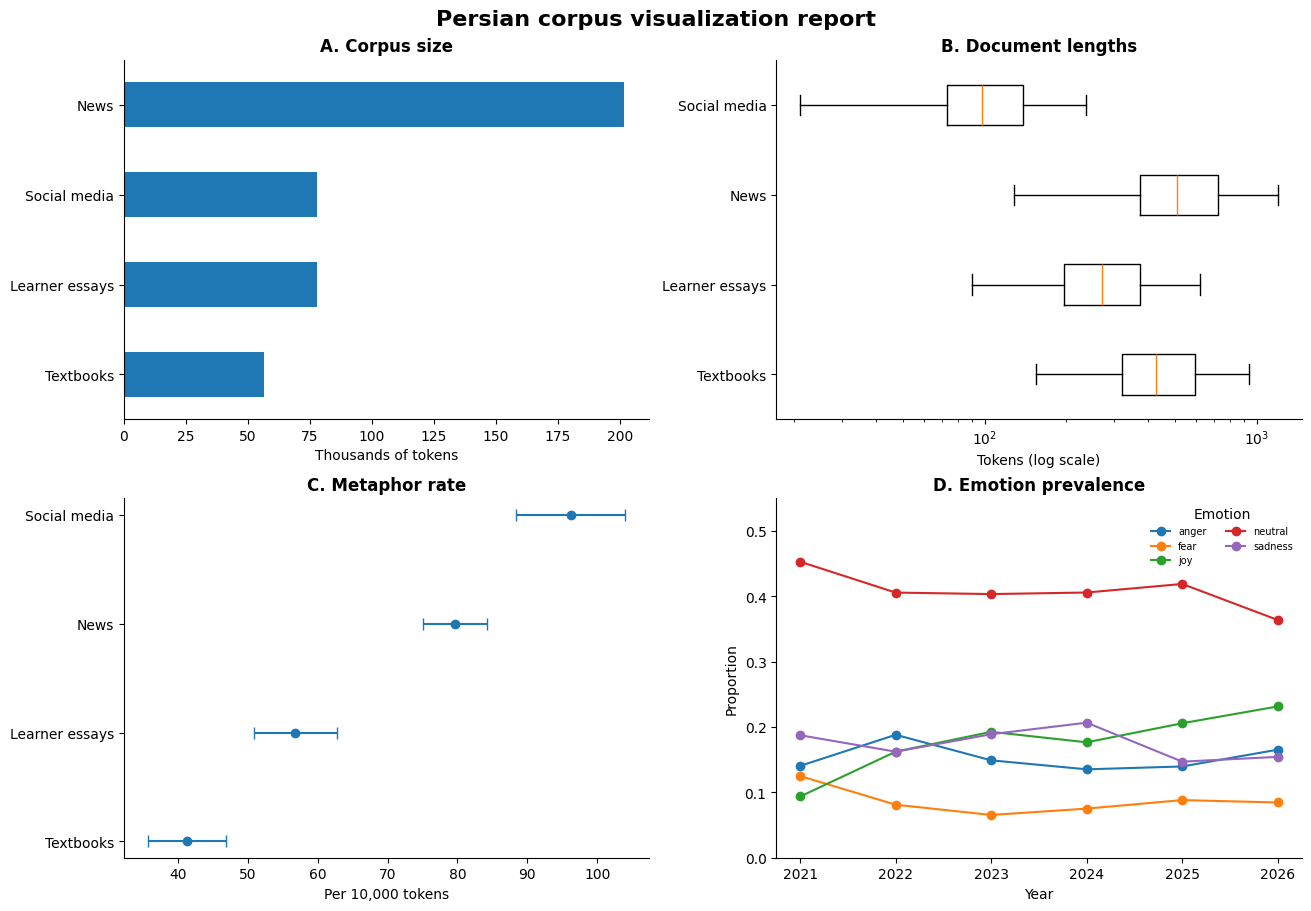

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), layout="constrained")

source_summary.sort_values("tokens")["tokens"].div(1_000).plot.barh(ax=axes[0, 0])
axes[0, 0].set(title="A. Corpus size", xlabel="Thousands of tokens", ylabel="")

axes[0, 1].boxplot(length_groups, tick_labels=source_order, vert=False, showfliers=False)
axes[0, 1].set(title="B. Document lengths", xlabel="Tokens (log scale)")
axes[0, 1].set_xscale("log")

ordered_metaphor = metaphor_summary.sort_values("mean")
metaphor_xerr = np.vstack([
    ordered_metaphor["mean"] - ordered_metaphor["low"],
    ordered_metaphor["high"] - ordered_metaphor["mean"],
])
axes[1, 0].errorbar(ordered_metaphor["mean"], ordered_metaphor.index, xerr=metaphor_xerr, fmt="o", capsize=4)
axes[1, 0].set(title="C. Metaphor rate", xlabel="Per 10,000 tokens", ylabel="")

emotion_proportions.plot(marker="o", ax=axes[1, 1])
axes[1, 1].set(title="D. Emotion prevalence", xlabel="Year", ylabel="Proportion", ylim=(0, 0.55))
axes[1, 1].legend(title="Emotion", ncols=2, fontsize=7)

fig.suptitle("Persian corpus visualization report", fontsize=16, fontweight="bold")
plt.show()


## 8. Interpretation

The synthetic corpus is intentionally unbalanced: social media supplies the largest number of documents, while news contributes many long documents and a substantial share of tokens. Document-length distributions differ sharply, so models trained on pooled data may partially learn source-specific length patterns. After normalization, metaphor rates are higher in news and social media, whereas learner essays have the highest error rate. Emotion prevalence changes modestly over time, but these trends should not be interpreted causally without checking source composition, annotation consistency, and sampling procedures.


## 9. Export the report

Save raster output for slides/web use and vector output for papers and later editing.


In [11]:
project_output = Path("figures/persian_corpus_project")
project_output.mkdir(parents=True, exist_ok=True)

for extension, options in {
    "png": {"dpi": 300},
    "svg": {},
    "pdf": {},
}.items():
    fig.savefig(project_output / f"persian_corpus_report.{extension}", bbox_inches="tight", **options)

source_summary.to_csv(project_output / "source_summary.csv")
metaphor_summary.to_csv(project_output / "metaphor_rate_summary.csv")

print("Project outputs saved to:", project_output.resolve())


Project outputs saved to: /mnt/data/04_matplotlib/figures/persian_corpus_project


## 10. Project checklist

- [x] Use document-level tidy data.
- [x] Audit missingness, duplicates, and impossible values.
- [x] Report both raw corpus size and normalized linguistic rates.
- [x] Use distributions rather than means alone.
- [x] Visualize time trends as within-year proportions.
- [x] Create a multi-panel final report.
- [x] Write an interpretation that distinguishes observation from causal explanation.
- [x] Export figures and summary tables.


## 11. Extension exercises

1. Add a `platform` column to social-media documents and compare emotion prevalence across platforms.
2. Bootstrap the metaphor rate by source instead of using a normal-approximation confidence interval.
3. Create a faceted document-length plot by source and year.
4. Add a quality-control panel showing missing annotations and duplicate IDs.
5. Replace the synthetic data generator with your own CSV while preserving the same report structure.


## 12. Reference solutions for two extensions


### Extension solution 1 — social-media platforms


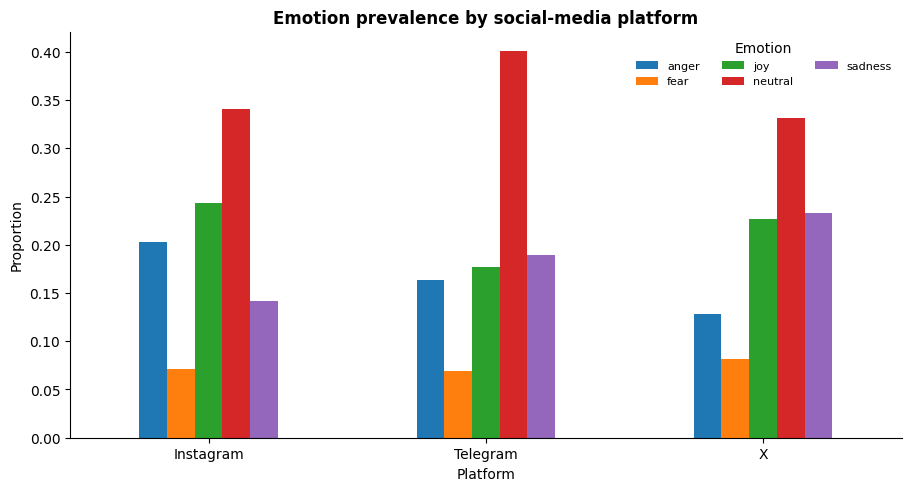

In [12]:
project_with_platform = corpus.copy()
social_mask = project_with_platform["source"].eq("Social media")
project_with_platform["platform"] = "Not applicable"
project_with_platform.loc[social_mask, "platform"] = RNG.choice(
    ["X", "Instagram", "Telegram"], size=social_mask.sum(), p=[0.25, 0.40, 0.35]
)

platform_emotions = pd.crosstab(
    project_with_platform.loc[social_mask, "platform"],
    project_with_platform.loc[social_mask, "emotion"],
    normalize="index",
)

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
platform_emotions.plot.bar(ax=ax)
ax.set(title="Emotion prevalence by social-media platform", xlabel="Platform", ylabel="Proportion")
ax.legend(title="Emotion", ncols=3, fontsize=8)
ax.tick_params(axis="x", rotation=0)
plt.show()


### Extension solution 2 — bootstrap confidence intervals


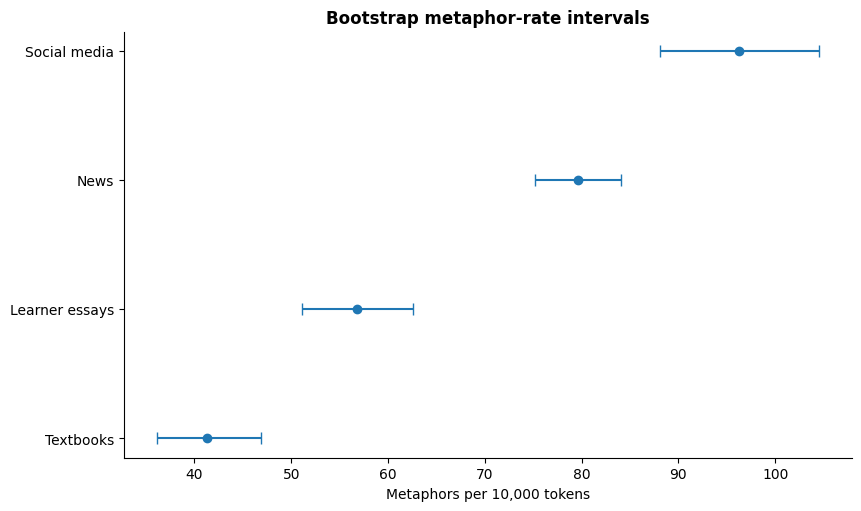

In [13]:
def bootstrap_mean_ci(values: pd.Series, *, n_boot: int = 1_000, seed: int = 42):
    rng = np.random.default_rng(seed)
    array = values.to_numpy()
    boot_means = np.array([
        rng.choice(array, size=len(array), replace=True).mean()
        for _ in range(n_boot)
    ])
    return pd.Series({
        "mean": array.mean(),
        "low": np.quantile(boot_means, 0.025),
        "high": np.quantile(boot_means, 0.975),
    })

bootstrap_summary = (
    corpus.groupby("source")["metaphors_per_10k"]
    .apply(bootstrap_mean_ci)
    .unstack()
    .sort_values("mean")
)

fig, ax = plt.subplots(layout="constrained")
bootstrap_xerr = np.vstack([
    bootstrap_summary["mean"] - bootstrap_summary["low"],
    bootstrap_summary["high"] - bootstrap_summary["mean"],
])
ax.errorbar(bootstrap_summary["mean"], bootstrap_summary.index, xerr=bootstrap_xerr, fmt="o", capsize=4)
ax.set(title="Bootstrap metaphor-rate intervals", xlabel="Metaphors per 10,000 tokens", ylabel="")
plt.show()


## References

- Matplotlib quick start: https://matplotlib.org/stable/users/explain/quick_start.html
- pandas visualization: https://pandas.pydata.org/docs/user_guide/visualization.html
- Matplotlib error bars: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html
- Saving figures: https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html
